In [4]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import sklearn
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential

In [5]:
# loading data
data=pd.read_csv(r"C:\Users\Prem\Desktop\ML projects\mnist.csv")
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# creating copy of data
df=data

In [21]:
df['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

#### so it is a multi class classifications of (0-9) - 10 classes

In [7]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# checking nulls
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.shape

(42000, 785)

### After cleaning data follow these steps for ANN model

In [20]:
# splitting 
x=df.drop('label',axis=1)
y=df['label']

In [15]:
print(x.shape)
print(y.shape)

(42000, 784)
(42000,)


#### No need of reshape as its flattened only for ANN

In [17]:
# normalization
x=x/255.0
# as it is an image data we should normalize for stability

In [18]:
# converting into arrays
x=np.array(x)
y=np.array(y)

In [23]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
# model building
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128,activation='relu'),  #neurons range to train(like 32, 64, 128, 256).
    keras.layers.Dropout(0.2),                  # deactivate 20% of neurons to prevent overfitting.
    keras.layers.Dense(10,activation='softmax')  # 10-out put classes/labels, softmax-multiclass classification.
])

In [35]:
# compilation
model.compile(
    optimizer='adam',
    loss=('sparse_categorical_crossentropy'),
    metrics=['accuracy'])

In [39]:
# train model
history = model.fit(x_train,y_train,epochs=26, validation_data=(x_test,y_test))

Epoch 1/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9364 - loss: 0.2550 - val_accuracy: 0.9376 - val_loss: 0.3511
Epoch 2/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9316 - loss: 0.2721 - val_accuracy: 0.9450 - val_loss: 0.3016
Epoch 3/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9344 - loss: 0.2563 - val_accuracy: 0.9452 - val_loss: 0.3696
Epoch 4/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9351 - loss: 0.2548 - val_accuracy: 0.9423 - val_loss: 0.4039
Epoch 5/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9353 - loss: 0.2497 - val_accuracy: 0.9450 - val_loss: 0.3747
Epoch 6/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9388 - loss: 0.2546 - val_accuracy: 0.9449 - val_loss: 0.3405
Epoch 7/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9391 - loss: 0.2466 - val_accuracy: 0.9405 - val_loss: 0.4134
Epoch 8/26
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9407 - loss: 0.2411 - 

In [40]:
# evaluation
model.evaluate(x_test,y_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9474 - loss: 0.4606


[0.46057620644569397, 0.9473809599876404]

In [41]:
# prediction
predictions = model.predict(x_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


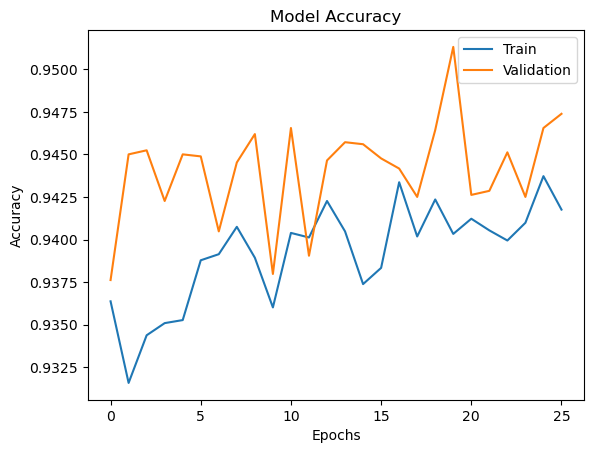

In [43]:
plt.plot(history.history['accuracy'])          # training accuracy
plt.plot(history.history['val_accuracy'])      # validation accuracy
plt.title('Model Accuracy')                    # title of graph
plt.xlabel('Epochs')                           # x-axis → epochs
plt.ylabel('Accuracy')                         # y-axis → accuracy
plt.legend(['Train', 'Validation'])            # labels
plt.show()